In [38]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler


In [15]:
DATA_DIR = r"C:\Users\Hp\Documents\Internships\Prodigy\Task 3\train"
IMG_SIZE = 64

In [16]:
# LOAD IMAGES 
def load_images(data_dir):
    data = []
    labels = []

    for label, category in enumerate(["cats", "dogs"]):
        folder_path = os.path.join(data_dir, category)
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            img = Image.open(img_path).convert("L")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img_array = np.array(img)
            data.append(img_array.flatten())
            labels.append(label)

    return np.array(data), np.array(labels)

print("Loading images...")
X, y = load_images(DATA_DIR)
print(f"Total samples: {X.shape[0]}")


Loading images...
Total samples: 190


In [17]:
# SCALE 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
# SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [19]:
# TRAIN SVM 
print("Training SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)
print("Done!")

Training SVM...
Done!


In [21]:
# EVALUATE 
y_pred = svm.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))

Accuracy: 60.53%
Classification Report:
              precision    recall  f1-score   support

         Cat       0.59      0.56      0.57        18
         Dog       0.62      0.65      0.63        20

    accuracy                           0.61        38
   macro avg       0.60      0.60      0.60        38
weighted avg       0.60      0.61      0.60        38



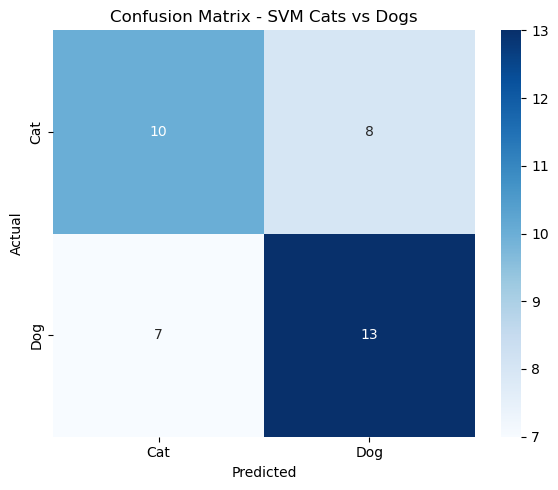

In [22]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Cat", "Dog"],
            yticklabels=["Cat", "Dog"])
plt.title("Confusion Matrix - SVM Cats vs Dogs")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

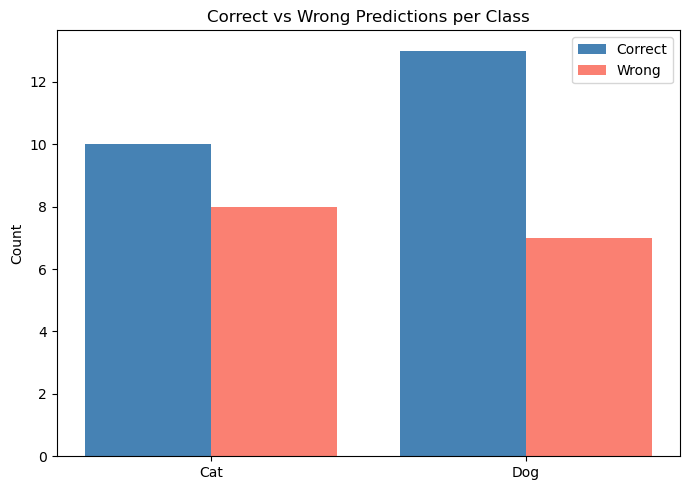

In [23]:
# ACCURACY BAR CHART 
categories = ["Cat", "Dog"]
correct = [
    sum((y_test == i) & (y_pred == i)) for i in range(2)
]
wrong = [
    sum((y_test == i) & (y_pred != i)) for i in range(2)
]

x = np.arange(len(categories))
plt.figure(figsize=(7, 5))
plt.bar(x - 0.2, correct, 0.4, label='Correct', color='steelblue')
plt.bar(x + 0.2, wrong, 0.4, label='Wrong', color='salmon')
plt.xticks(x, categories)
plt.title("Correct vs Wrong Predictions per Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_bar.png")
plt.show()


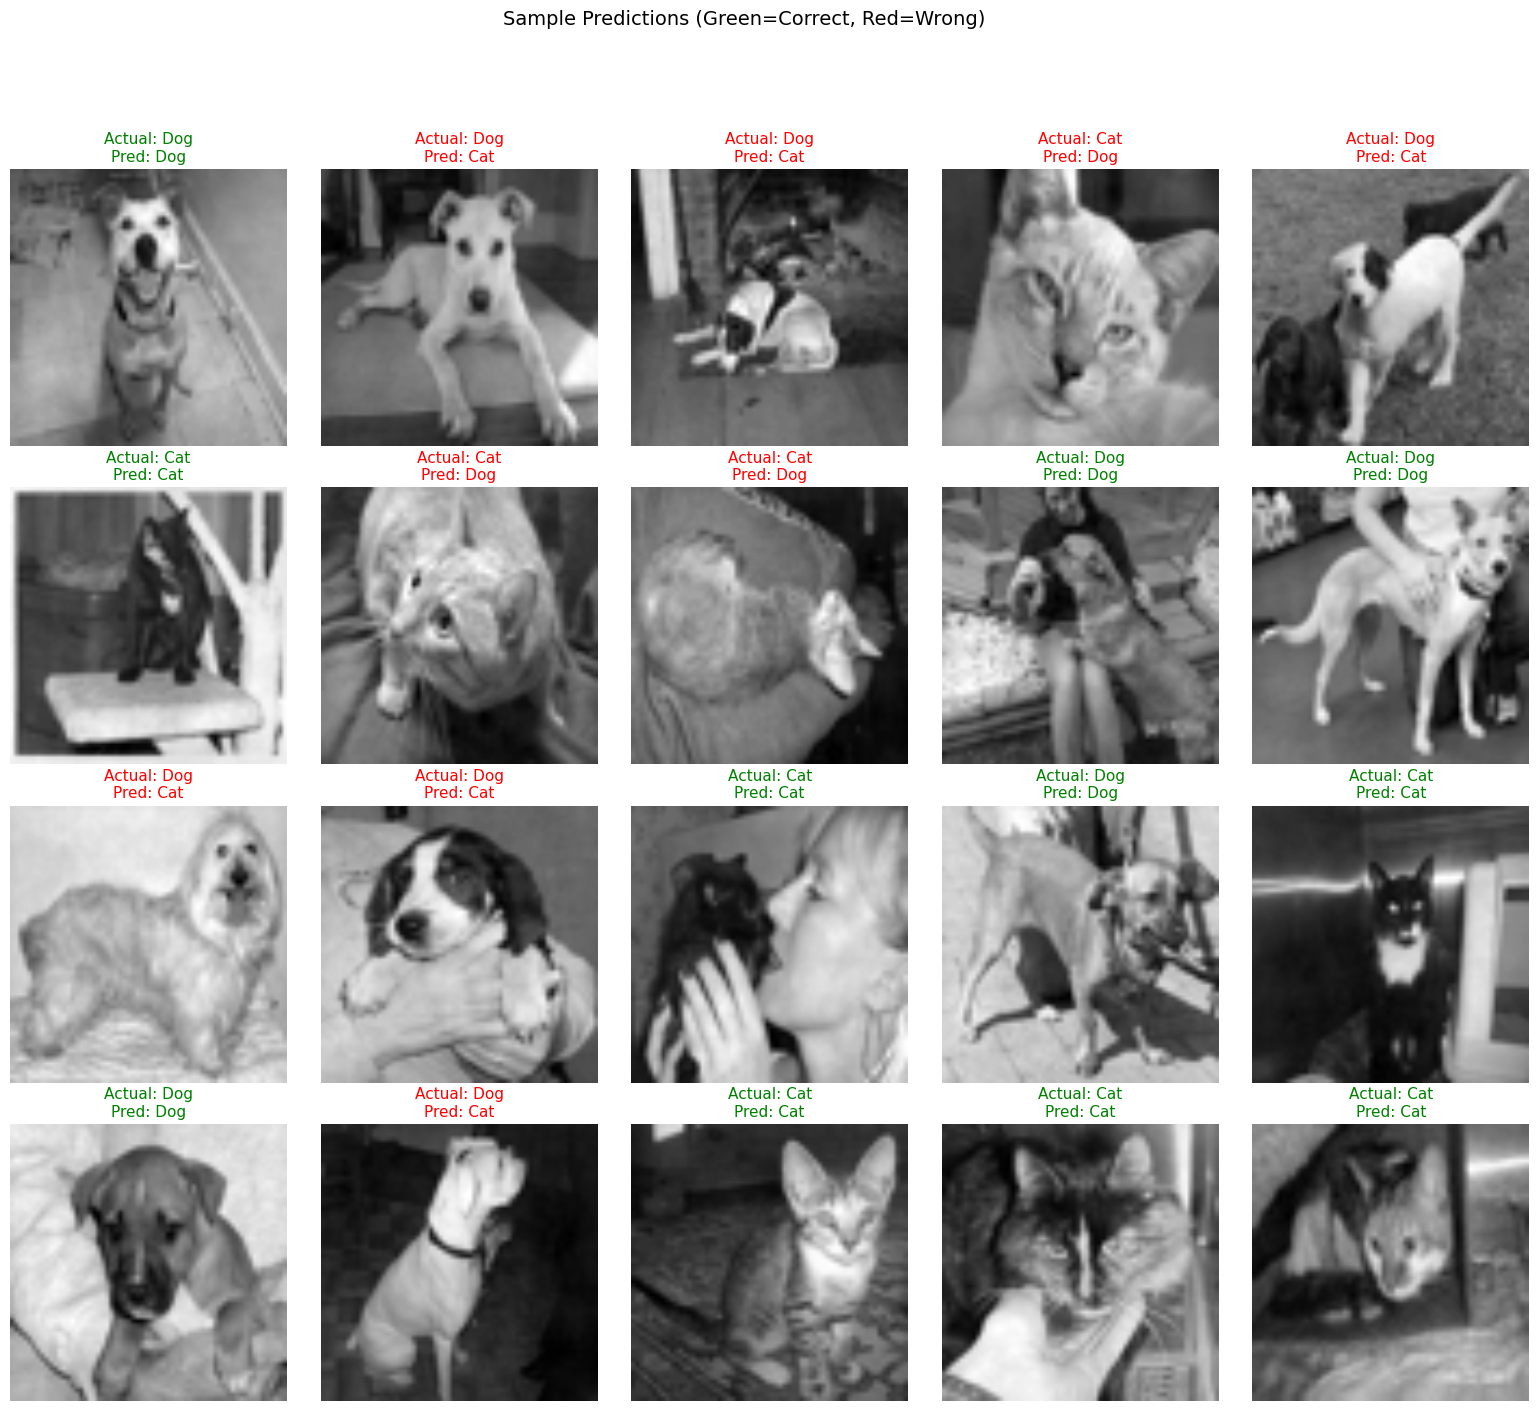

In [36]:
# SAMPLE PREDICTIONS 
class_names = ["Cat", "Dog"]
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

n_samples = min(20, len(X_test))

for i in range(n_samples):
    img = X_test[i].reshape(IMG_SIZE, IMG_SIZE)
    axes[i].imshow(img, cmap='gray', interpolation='bilinear')
    actual = class_names[y_test[i]]
    predicted = class_names[y_pred[i]]
    color = "green" if actual == predicted else "red"
    axes[i].set_title(f"Actual: {actual}\nPred: {predicted}",
                      color=color, fontsize=11)
    axes[i].axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.subplots_adjust(wspace=0.01, hspace=0.15) 
plt.savefig("sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()